### Ejemplo de Reparto de Coste Unitario para el juego de la *Cadena* de Myerson

Se tata de la situación de comnicación de Myerson representado por la cadena abajo dibujada. La matriz de adyacencia de este grafo es la siguiente:

$$ \begin{bmatrix}
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0
\end{bmatrix} $$

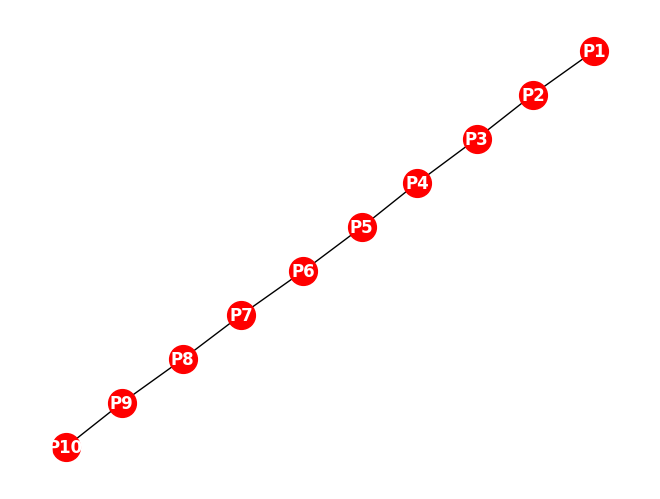

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

adjacency = pd.DataFrame([
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
])
index = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7",
    "P8",
    "P9",
    "P10",
]
adjacency.columns = index
adjacency["index"] = index
adjacency = adjacency.set_index("index", verify_integrity=True)

g = nx.from_pandas_adjacency(adjacency)
pos = nx.kamada_kawai_layout(g)
nx.draw(
    g, pos, with_labels=True,
    node_color="red", font_color="white",
    font_weight="bold", node_size=400
)

In [ ]:
import os
import sys
import math
import pandas as pd


sys.path.append(os.path.join("..", "..", "."))

file_root_shapley = os.path.join(
    "..", "..", "data", "exact", "shapley_cost_value_of_myerson_chain.csv"
)
file_root_grabisch = os.path.join(
    "..", "..", "data", "exact", "grabisch_of_myerson_chain.csv"
)

index = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7",
    "P8",
    "P9",
    "P10",
]
shapley_only = pd.read_csv(
    file_root_shapley,
    sep=";",
    header=None,
    names=["value"]
)
shapley_only["player"] = index
psi_1 = shapley_only.set_index("player", verify_integrity=True)

r_1 = pd.read_csv(
    file_root_grabisch,
    sep=";",
    header=0
)
r_1.columns = index
r_1["player"] = index
r_1 = r_1.set_index("player", verify_integrity=True)

### Truncated characteristic values

In [3]:
from graph.manipulation import normalize_psi, normalize_r


n = 4
psi_1_truncated = psi_1.copy()
psi_1_truncated["value"] = psi_1_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_1_truncated = r_1.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

psi_2 = normalize_psi(psi_1)
psi_2_truncated = psi_2.copy()
psi_2_truncated["value"] = psi_2_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_2 = normalize_r(r_1)
r_2_truncated = r_2.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

#### Cost Allocation Results

The Shapley values for this game are calculated in the file ./data/exact/shapley_value_of_myerson_coalitions_chain.csv. In the table below we represent these values:

In [4]:
psi_1_truncated

,value
player,
P1,-0.5
P2,0.0
P3,0.0
P4,0.0
P5,0.0
P6,0.0
P7,0.0
P8,0.0
P9,0.0


In [5]:
psi_2_truncated

,value
player,
P1,-1.0
P2,0.0
P3,0.0
P4,0.0
P5,0.0
P6,0.0
P7,0.0
P8,0.0
P9,0.0


The Grabisch values of all the pairs in the game can be found in the file ./data/exact/grabisch_of_myerson_coalitions_chain.csv. In the following table, we represent these values.

In [6]:
r_1_truncated

,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
player,,,,,,,,,,
P1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
P4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
P5,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
P6,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
P7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
P8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
P9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [7]:
r_2_truncated

,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
player,,,,,,,,,,
P1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
P4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
P5,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
P6,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
P7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
P8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
P9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 0}^{2}; R_{\beta^{+} = 0, \beta^{-} = 0}^{2}$

In [8]:
import os
import sys
sys.path.append(os.path.join("..", "..", "."))

from graph.visualization import draw

draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=0,
    negative_alpha=0,
    positive_beta=0,
    negative_beta=0,
    symmetric=True,
    layout="kamada_kawai",
    output_path=os.path.join("..", "..", "results", "myerson-chain-cost-0-0-0-0.jpg")
)

..\..\.\graph\visualization.py:204: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


Saving the graph to ..\..\results\myerson-chain-cost-0-0-0-0.jpg


## Histogram and Density Plots

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools
import networkx as nx


In [10]:
r1_positive = r_1.copy(deep=True)
r1_positive[r1_positive < 0] = 0
r1_positive

r1_negative = r_1.copy(deep=True)
r1_negative[r1_negative > 0] = 0
r1_negative = r1_negative.abs()

s_plus = []
for column_name in r1_positive.columns:
    strength = r1_positive.loc[column_name].sum()
    s_plus.append(math.floor(strength * 10 ** n) / 10 ** n)
s_plus.sort()

s_minus = []
for column_name in r1_negative.columns:
    strength = r1_negative.loc[column_name].sum()
    s_minus.append(math.floor(strength * 10 ** n) / 10 ** n)
s_minus.sort()

s = []
for column_name in r_1.columns:
    strength = r_1.loc[column_name].sum()
    s.append(math.floor(strength * 10 ** n) / 10 ** n)
s.sort()

s_abs = []
for column_name in r_1.columns:
    strength = r_1.abs().loc[column_name].sum()
    s_abs.append(math.floor(strength * 10 ** n) / 10 ** n)
s_abs.sort()

## Profiling

In [11]:
profile = pd.DataFrame(
    columns=["game", "parameter", "R = I+", "R = I-", "R = I", "R = |I|"]
)
game = "myerson-cost-chain"

### Stats

In [12]:
import numpy as np
from scipy.stats import skew, kurtosis

profile.loc[len(profile)] = [
    game,
    "max",
    np.max(s_plus),
    np.max(s_minus),
    np.max(s),
    np.max(s_abs),
]

profile.loc[len(profile)] = [
    game,
    "Q3",
    np.percentile(s_plus, 75),
    np.percentile(s_minus, 75),
    np.percentile(s, 75),
    np.percentile(s_abs, 75),
]

profile.loc[len(profile)] = [
    game,
    "mean",
    np.mean(s_plus),
    np.mean(s_minus),
    np.mean(s),
    np.mean(s_abs),
]

profile.loc[len(profile)] = [
    game,
    "median",
    np.median(s_plus),
    np.median(s_minus),
    np.median(s),
    np.median(s_abs),
]

profile.loc[len(profile)] = [
    game,
    "Q1",
    np.percentile(s_plus, 25),
    np.percentile(s_minus, 25),
    np.percentile(s, 25),
    np.percentile(s_abs, 25),
]

profile.loc[len(profile)] = [
    game,
    "min",
    np.min(s_plus),
    np.min(s_minus),
    np.min(s),
    np.min(s_abs),
]

profile.loc[len(profile)] = [
    game,
    "standard_deviation",
    np.std(s_plus),
    np.std(s_minus),
    np.std(s),
    np.std(s_abs),
]

profile.loc[len(profile)] = [
    game,
    "skewness",
    0 if np.isnan(skew(s_plus)) else skew(s_plus),
    0 if np.isnan(skew(s_minus)) else skew(s_minus),
    0 if np.isnan(skew(s)) else skew(s),
    0 if np.isnan(skew(s_abs)) else skew(s_abs),
]

profile.loc[len(profile)] = [
    game,
    "kurtosis",
    0 if np.isnan(kurtosis(s_plus)) else kurtosis(s_plus),
    0 if np.isnan(kurtosis(s_minus)) else kurtosis(s_minus),
    0 if np.isnan(kurtosis(s)) else kurtosis(s),
    0 if np.isnan(kurtosis(s_abs)) else kurtosis(s_abs),
]

### Gini index

If we assign the strength of a player as the sum of all its connection in the relation matrix $r_{ij} \in N \times N$ with $n = |N|$ players

$$
s_{i} = \sum_{j \in N} r_{ij}
$$

We can compute the Gini index of a total resource $T$ defined as:

$$
T = \sum_{i \in N}{s_{i}}
$$

As described by Goswami (2021)[1] when $T_{1} = T$:

$$
SI(G) = 1 - \frac{2}{nT_{1}}\sum_{i \in N}{\left(n -i + \frac{1}{2}\right)s_{i}}
$$


[1] Goswami, S., Das, A. K., & Nandy, S. C. (2021). Sparsity of weighted networks: Measures and applications. Information Sciences, 577, 557–578. https://doi.org/10.1016/j.ins.2021.06.090


In [13]:
import os
import sys
sys.path.append(os.path.join("..", "..", "."))

from graph.parameters import gini


profile.loc[len(profile)] = [
    game,
    "gini",
    gini(s_plus),
    gini(s_minus),
    gini(s),
    gini(s_abs),
]

### Degree centralization of the Graph

The degree centralization of a Graph was described by Freeman (1978)[2] as the ratio of the differences sum of degree of each node with the highest degree by the one that maximizes this value, the star graph:

$$
s_{i}^{*} = \max_{i} \left(s_{i}\right)
$$
$$
C_{D}(G) = \frac{\sum_{i \in N}{s_{i}^{*} - s_{i}}}{n^{2} - 3 n + 2}
$$

[2] Freeman, L. C. (1978). Centrality in social networks conceptual clarification. Social Networks, 1(3), 215–239. https://doi.org/10.1016/0378-8733(78)90021-7

In [14]:
import os
import sys
sys.path.append(os.path.join("..", "..", "."))

from graph.parameters import degree_centralization


profile.loc[len(profile)] = [
    game,
    "degree_centralization",
    degree_centralization(s_plus),
    degree_centralization(s_minus),
    degree_centralization(s),
    degree_centralization(s_abs),
]

### Characteristic path length

Defined by Antoniou et al. (2008) [4] as:

$$
\tilde{w} = \frac{T}{|W|}
$$

where $W = [w_{ij}]$ is the set of edges weights in the weighted graph.

[4] Antoniou, I. E., & Tsompa, E. T. (2008). Statistical Analysis of Weighted Networks. Discrete Dynamics in Nature and Society, 2008, 1–16. https://doi.org/10.1155/2008/375452

In [15]:
import os
import sys
sys.path.append(os.path.join("..", "..", "."))

from graph.parameters import characteristic_path_length


profile.loc[len(profile)] = [
    game,
    "characteristic_path_length",
    characteristic_path_length(s_plus),
    characteristic_path_length(s_minus),
    characteristic_path_length(s),
    characteristic_path_length(s_abs),
]

### Output results

In [16]:
import os

display(profile)

profiling_output = os.path.join(
    "..", "..", "data", "profiling", f"{game}.csv"
)

profile.to_csv(profiling_output, sep=";", index=False)

,game,parameter,R = I+,R = I-,R = I,R = |I|
0,myerson-cost-chain,max,2.000000,0.0,2.000000,2.000000
1,myerson-cost-chain,Q3,2.000000,0.0,2.000000,2.000000
2,myerson-cost-chain,mean,1.800000,0.0,1.800000,1.800000
3,myerson-cost-chain,median,2.000000,0.0,2.000000,2.000000
4,myerson-cost-chain,Q1,2.000000,0.0,2.000000,2.000000
5,myerson-cost-chain,min,1.000000,0.0,1.000000,1.000000
6,myerson-cost-chain,standard_deviation,0.400000,0.0,0.400000,0.400000
7,myerson-cost-chain,skewness,-1.500000,0.0,-1.500000,-1.500000
8,myerson-cost-chain,kurtosis,0.250000,0.0,0.250000,0.250000
9,myerson-cost-chain,gini,0.088889,0.0,0.088889,0.088889
